In [79]:
# Data handling and manipulation library
import pandas as pd

# Library for numerical operations in Python
import numpy as np

# Visualizations library
import matplotlib.pyplot as plt

# Exploratory visualizations library
import seaborn as sns

# Statistical functions library
from scipy import stats

import os

from pathlib import Path

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)


In [80]:
# Load raw CSVs
t2d  = pd.read_csv("../files/T2D.csv", sep=";", encoding="latin-1")
mob  = pd.read_csv("../files/Morbidly_Obese.csv", sep=";", encoding="latin-1")
ltd  = pd.read_csv("../files/Longterm_Disease.csv", sep=";", encoding="latin-1")
fbc  = pd.read_csv("../files/Fraction_Blood_Clot.csv", sep=";", encoding="latin-1")
edu  = pd.read_csv("../files/Education_Long.csv", sep=";", encoding="latin-1")
who  = pd.read_csv("../files/WHO_Minimum_Physical_Activity.csv", sep=";", encoding="latin-1")
life = pd.read_csv("../files/Life_Expectancy.csv", sep=";", encoding="latin-1")
absn = pd.read_csv("../files/Absence.csv", sep=";", encoding="latin-1")
sab = pd.read_csv("../files/Sales-Bricks.csv", sep=";", encoding="latin-1")

# Optional datasets (not merged on brick level here)
attn = pd.read_csv("../files/Attention.csv", sep=";", encoding="latin-1")
pdat = pd.read_csv("../files/Patient_Data.csv", sep=";", encoding="latin-1")

dataframes = {
    "t2d": t2d,
    "mob": mob,
    "ltd": ltd,
    "fbc": fbc,
    "edu": edu,
    "who": who,
    "life": life,
    "absn": absn,
    "sab": sab,
}

# Quick inspect
print(t2d.shape);  print(t2d.head(3))


(60, 5)
   brick_nr          brick     patients  population patients_per_1000
0       101       Bornholm  2248,978472       33046       68,05599685
1       102         Amager  6136,772115      154254       39,78355255
2       103  Nørrebro/City  3019,148357       88293       34,19465141


In [81]:
# Quick per-file inspection
for name, df in dataframes.items():
    print("===")
    print(name)
    print("shape:", df.shape)
    print("columns:", list(df.columns[:10]) + (["..."] if len(df.columns)>10 else []))
    print("dtypes (top):")
    print(df.dtypes[:10])
    print("missing (top 8):")
    print(df.isna().sum().sort_values(ascending=False).head(8))
    print()


===
t2d
shape: (60, 5)
columns: ['brick_nr', 'brick', 'patients', 'population', 'patients_per_1000']
dtypes (top):
brick_nr              int64
brick                object
patients             object
population            int64
patients_per_1000    object
dtype: object
missing (top 8):
brick_nr             0
brick                0
patients             0
population           0
patients_per_1000    0
dtype: int64

===
mob
shape: (60, 3)
columns: ['brick_nr', 'brick', 'Andel']
dtypes (top):
brick_nr     int64
brick       object
Andel       object
dtype: object
missing (top 8):
brick_nr    0
brick       0
Andel       0
dtype: int64

===
ltd
shape: (60, 3)
columns: ['brick_nr', 'brick', 'anddel']
dtypes (top):
brick_nr     int64
brick       object
anddel      object
dtype: object
missing (top 8):
brick_nr    0
brick       0
anddel      0
dtype: int64

===
fbc
shape: (60, 3)
columns: ['brick_nr', 'brick', 'Andel med blodprop i hjertet']
dtypes (top):
brick_nr                         int64
bri

In [82]:
# Now we will clean and standardize the columns of all the datasets so we can merge them afterwards

# We'll loop through all the DataFrames again
for name, df in dataframes.items():
    # Create a cleaned version of each column name
    cleaned_columns = []
    for col in df.columns:
        new_col = (
            col.strip()            # remove leading/trailing spaces
               .lower()            # convert to lowercase
               .replace(" ", "_")  # replace spaces with underscores
               .replace("-", "_")  # replace dashes with underscores
        )
        for ch in "()[]{}$%#@!":
            new_col = new_col.replace(ch, "")
        cleaned_columns.append(new_col)

    # Apply the cleaned column names to the DataFrame
    df.columns = cleaned_columns

    # Update the DataFrame in the dictionary
    dataframes[name] = df

# Show the cleaned column names for each dataset
for name, df in dataframes.items():
    print(f"{name}: {list(df.columns)}")


t2d: ['brick_nr', 'brick', 'patients', 'population', 'patients_per_1000']
mob: ['brick_nr', 'brick', 'andel']
ltd: ['brick_nr', 'brick', 'anddel']
fbc: ['brick_nr', 'brick', 'andel_med_blodprop_i_hjertet']
edu: ['brick_nr', 'brick', 'antal', 'brick_navn', 'population', 'value_per_1000']
who: ['brick_nr', 'brick', 'andel']
life: ['brick_nr', 'brick', 'år']
absn: ['brick_nr', 'brick', 'fravær']
sab: ['year_month', 'brick_code', 'volume', 'value', 'market']


In [83]:
# Rename the brick_code to brick_nr
sab.columns = ['year_month', 'brick_nr','volume','value','market']


In [84]:
# Make all column names lowercase and remove extra spaces
sab.columns = sab.columns.str.strip().str.lower()

# Converting volume and value to numeric
for c in ("volume", "value"):
    sab[c] = pd.to_numeric(
        sab[c].astype(str)
              .str.replace(r"[^0-9,.\-]", "", regex=True)  # fjern alt undtagen tal , . -
              .str.replace(".", "", regex=False)           # fjern tusindtals-punktum
              .str.replace(",", ".", regex=False),         # decimalkomma -> punktum
        errors="coerce"
    )

# Pivot the data so each market becomes a separate column for both volume and value
pivot = sab.pivot_table(
    index="brick_nr",
    columns="market",
    values=["volume", "value"],
    aggfunc="sum",
    fill_value=0
)

# Flatten the multi-level column names
pivot.columns = [f"{a}_{b}" for a, b in pivot.columns]
pivot = pivot.reset_index()

pivot


,brick_nr,value_DPP-IV,value_GLP-1,value_Metformin,value_New generation insulin in basal,value_SGLT-2,volume_DPP-IV,volume_GLP-1,volume_Metformin,volume_New generation insulin in basal,volume_SGLT-2
0,101,663029.93,4206135.32,154482.57,1734336.64,743326.79,1224,4832,12808,3737,1156
1,102,3219103.19,9227040.07,529689.23,4366710.75,4051905.06,6026,10647,36297,10088,5392
2,103,1322399.98,2881603.88,202458.72,1964112.71,1784510.95,2687,3048,15405,4687,2637
3,104,1573993.89,4213623.21,216250.90,2193008.79,1878387.76,2926,4728,16713,5198,2728
4,105,1758488.68,5133362.55,267224.83,2491994.70,2283338.87,3099,5592,20406,5956,3212
...,...,...,...,...,...,...,...,...,...,...,...
57,506,1711065.29,4404252.48,254735.84,2817354.00,2015311.69,2864,4892,21570,7047,3044
58,507,1381766.18,3329583.70,208498.90,2898910.33,1816032.31,2187,3746,16662,7069,2520
59,508,2194094.26,2914704.22,282860.83,2484561.48,2092425.63,3976,3379,20311,6338,3312
60,601,868615.58,4443717.85,214098.32,1650414.15,1393899.79,1086,5004,16603,3298,1531


In [85]:
# Saving it as a csv file
pivot.to_csv('sales_volume_value.csv', index=False)

In [86]:
# year_month as text
sab["year_month"] = sab["year_month"].astype(str)

# Gruppér på år + market
trend = (
    sab.groupby(["year_month", "market"], as_index=False)[["volume", "value"]]
       .sum()
       .sort_values(["market", "year_month"])
)

trend["year"] = trend["year_month"].str[:4]
yearly = trend.groupby(["year", "market"], as_index=False)[["volume", "value"]].sum()
yearly


,year,market,volume,value
0,2019,DPP-IV,92959,4.990018e+07
1,2019,GLP-1,168979,1.600901e+08
2,2019,Metformin,622739,7.136435e+06
3,2019,New generation insulin in basal,200145,8.237466e+07
4,2019,SGLT-2,90093,6.136472e+07
5,2020,DPP-IV,112168,6.016753e+07
6,2020,GLP-1,211939,1.752846e+08
7,2020,Metformin,762621,1.037056e+07
8,2020,New generation insulin in basal,239226,1.011909e+08
9,2020,SGLT-2,121686,8.196216e+07


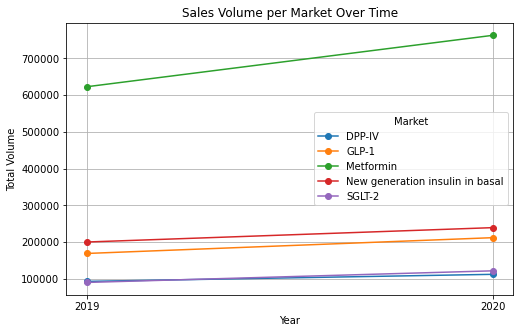

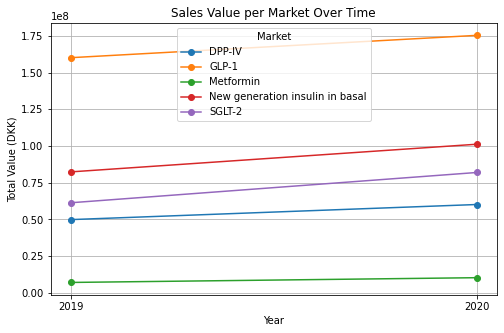

In [87]:
# Plot: Volume over time per market
plt.figure(figsize=(8, 5))
for m in yearly["market"].unique():
    subset = yearly[yearly["market"] == m]
    plt.plot(subset["year"], subset["volume"], marker="o", label=m)

plt.title("Sales Volume per Market Over Time")
plt.xlabel("Year")
plt.ylabel("Total Volume")
plt.legend(title="Market")
plt.grid(True)
plt.show()


# Plot: Value over time per market
plt.figure(figsize=(8, 5))
for m in yearly["market"].unique():
    subset = yearly[yearly["market"] == m]
    plt.plot(subset["year"], subset["value"], marker="o", label=m)

plt.title("Sales Value per Market Over Time")
plt.xlabel("Year")
plt.ylabel("Total Value (DKK)")
plt.legend(title="Market")
plt.grid(True)
plt.show()


In [88]:
# Step 1: Strip and normalize
attn.columns = attn.columns.str.strip().str.lower()

for col in ["brick_no", "who_atc_code", "category"]:
    attn[col] = attn[col].astype(str).str.strip()  # removes invisible spaces or linebreaks
    attn.loc[attn[col].isin(["", "nan", "None"]), col] = None  # treat empty strings as NaN

# Step 2: Group again cleanly
att_grouped = (
    attn.groupby(["period_id", "brick_no", "who_atc_code", "category"], as_index=False)["count_"]
       .sum()
       .rename(columns={"count_": "clicks"})
)

# Renaming columns
att_grouped.columns = ['period_id','brick_nr','who_atc_code','market','clicks']

att_grouped


,period_id,brick_nr,who_atc_code,market,clicks
0,201907,101,A10AE04,New generation insulin in basal,7
1,201907,101,A10AE06,New generation insulin in basal,6
2,201907,101,A10BA02,Metformin,4
3,201907,101,A10BD08,DPP-IV,2
4,201907,101,A10BH05,DPP-IV,2
...,...,...,...,...,...
13336,202006,Outside DK,A10BJ06,GLP-1,125
13337,202006,Outside DK,A10BK01,SGLT-2,3636
13338,202006,Outside DK,A10BK02,SGLT-2,25
13339,202006,Outside DK,A10BK03,SGLT-2,3709


In [89]:
# Filter only GLP-1
att_glp1 = att_grouped[att_grouped["market"].str.upper() == "GLP-1"]

# Looking at the trend over time
glp1_trend = (
    att_glp1.groupby("period_id", as_index=False)["clicks"]
            .sum()
            .sort_values("period_id")
)

glp1_trend


,period_id,clicks
0,201907,3592
1,201908,4222
2,201909,5128
3,201910,4572
4,201911,5896
5,201912,8786
6,202001,4870
7,202002,4579
8,202003,3855
9,202004,3517


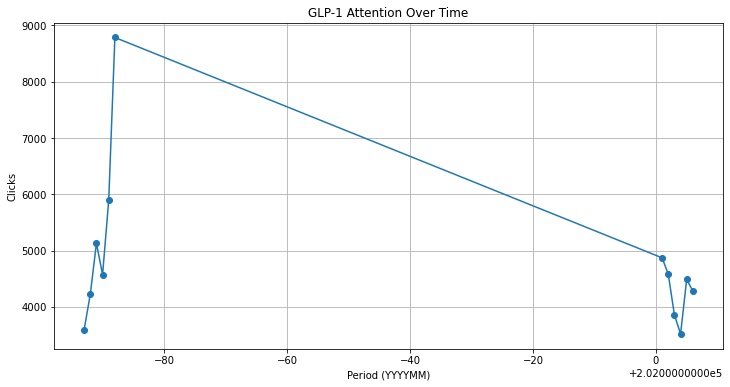

In [90]:
# Plotting the trend 

plt.figure(figsize=(12,6))
plt.plot(glp1_trend["period_id"], glp1_trend["clicks"], marker="o")
plt.title("GLP-1 Attention Over Time")
plt.xlabel("Period (YYYYMM)")
plt.ylabel("Clicks")
plt.grid(True)
plt.show()


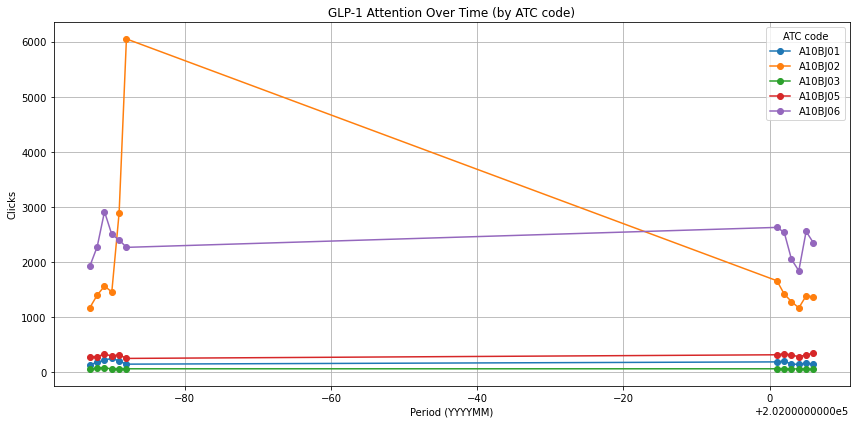

In [91]:
# Filter only GLP-1
att_glp1 = att_grouped[att_grouped["market"].str.upper() == "GLP-1"]

# Group by month and ATC code
glp1_trend = (
    att_glp1.groupby(["period_id", "who_atc_code"], as_index=False)["clicks"]
            .sum()
            .sort_values(["who_atc_code", "period_id"])
)

# Plot one line per ATC code
plt.figure(figsize=(12,6))
for code in glp1_trend["who_atc_code"].unique():
    subset = glp1_trend[glp1_trend["who_atc_code"] == code]
    plt.plot(subset["period_id"], subset["clicks"], marker="o", label=code)

plt.title("GLP-1 Attention Over Time (by ATC code)")
plt.xlabel("Period (YYYYMM)")
plt.ylabel("Clicks")
plt.legend(title="ATC code")
plt.grid(True)
plt.tight_layout()
plt.show()


In [92]:
# Focus on GLP-1 market only
att_glp1 = att_grouped[att_grouped["market"].str.upper() == "GLP-1"]

# Group by month, brick, and ATC code
glp1_brick = (
    att_glp1.groupby(["period_id", "brick_nr", "who_atc_code"], as_index=False)["clicks"]
             .sum()
)
glp1_brick


,period_id,brick_nr,who_atc_code,clicks
0,201907,101,A10BJ02,2
1,201907,101,A10BJ06,5
2,201907,102,A10BJ01,1
3,201907,102,A10BJ02,23
4,201907,102,A10BJ03,1
...,...,...,...,...
2511,202006,Outside DK,A10BJ01,16
2512,202006,Outside DK,A10BJ02,115
2513,202006,Outside DK,A10BJ03,7
2514,202006,Outside DK,A10BJ05,30


In [104]:
# We want to focus on two specific code: A10BJ06 and A10BJ02
focus_codes = ["A10BJ06", "A10BJ02"]

glp1_focus = (
    glp1_brick[glp1_brick["who_atc_code"].isin(focus_codes)]
    .groupby(["brick_nr", "who_atc_code"], as_index=False)["clicks"]
    .sum()
)


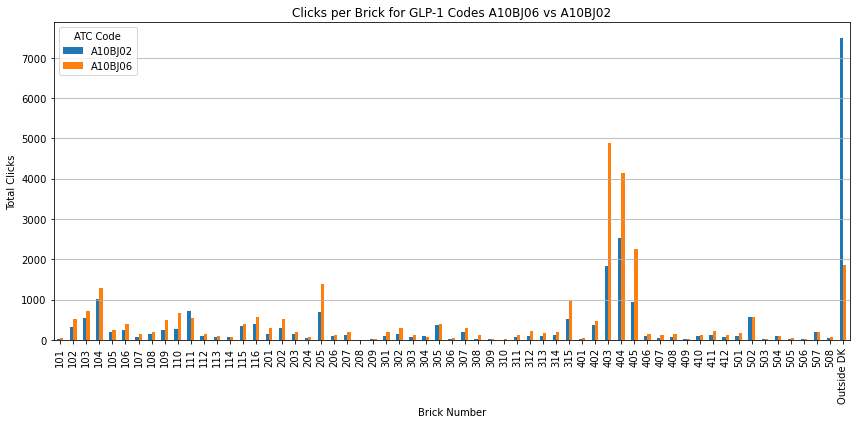

In [94]:
# Find total clicks per brick across both codes
bricks = (
    glp1_focus.groupby("brick_nr")["clicks"].sum()
    .sort_values(ascending=False)
    .index
)

# Filter for bricks only
glp1_top = glp1_focus[glp1_focus["brick_nr"].isin(bricks)]

# Barplot comparison per brick
pivot_plot = glp1_top.pivot(index="brick_nr", columns="who_atc_code", values="clicks").fillna(0)
pivot_plot.plot(kind="bar", figsize=(12,6))

plt.title("Clicks per Brick for GLP-1 Codes A10BJ06 vs A10BJ02")
plt.xlabel("Brick Number")
plt.ylabel("Total Clicks")
plt.legend(title="ATC Code")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


In [95]:
# Rename for consistent keys
sales = sab.copy()
sales.columns = sales.columns.str.lower()
sales["year_month"] = sales["year_month"].astype(str)
sales["brick_nr"] = sales["brick_nr"].astype(str)

# prepare attention data
att_merged = att_grouped.copy()
att_merged["period_id"] = att_merged["period_id"].astype(str)
att_merged["brick_nr"] = att_merged["brick_nr"].astype(str)
att_merged["market"] = att_merged["market"].str.strip()


In [ ]:
merged = pd.merge(
    sales,
    att_merged,
    left_on=["year_month", "brick_nr", "market"],
    right_on=["period_id", "brick_nr", "market"],
    how="inner"
)


In [97]:
trend_all = (
    merged.groupby("year_month", as_index=False)[["clicks", "volume", "value"]]
           .sum()
)
trend_all

,year_month,clicks,volume,value
0,201907,11515,544217,2.720991e+08
1,201908,13463,531370,2.694284e+08
2,201909,19954,541781,2.783884e+08
3,201911,16705,537760,2.755312e+08
4,201912,14908,627305,3.270708e+08
5,202001,18135,568514,2.903851e+08
6,202002,17370,587397,2.992848e+08
7,202003,14181,652980,3.206404e+08
8,202004,13442,470285,2.209790e+08
9,202005,15372,563695,2.771362e+08


In [127]:
focus_codes = ["A10BJ06", "A10BJ02"]
merged_glp1 = merged[
    (merged["market"].str.upper() == "GLP-1") &
    (merged["who_atc_code"].isin(focus_codes))
]

merged_glp1

,year_month,brick_nr,volume,value,market,period_id,who_atc_code,clicks
3677,201907,101,414,416640.42,GLP-1,201907,A10BJ02,2
3678,201907,101,414,416640.42,GLP-1,201907,A10BJ06,5
3680,201907,102,980,949179.04,GLP-1,201907,A10BJ02,23
3683,201907,102,980,949179.04,GLP-1,201907,A10BJ06,26
3685,201907,103,249,255593.27,GLP-1,201907,A10BJ02,52
...,...,...,...,...,...,...,...,...
5924,202006,506,432,364427.69,GLP-1,202006,A10BJ02,2
5926,202006,507,342,269583.51,GLP-1,202006,A10BJ02,28
5928,202006,507,342,269583.51,GLP-1,202006,A10BJ06,20
5929,202006,508,328,259445.35,GLP-1,202006,A10BJ02,5


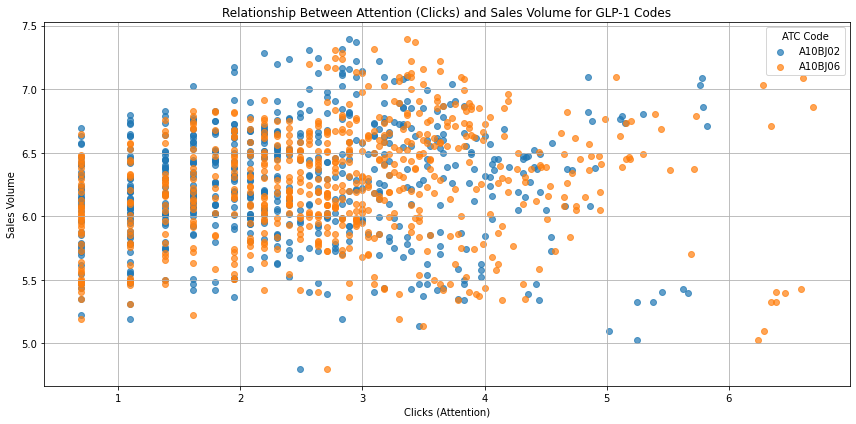

In [112]:
plt.figure(figsize=(12,6))
for code in focus_codes:
    subset = merged_glp1[merged_glp1["who_atc_code"] == code]
    plt.scatter(np.log1p(subset["clicks"]), np.log1p(subset["volume"]), label=code, alpha=0.7)

plt.title("Relationship Between Attention (Clicks) and Sales Volume for GLP-1 Codes")
plt.xlabel("Clicks (Attention)")
plt.ylabel("Sales Volume")
plt.legend(title="ATC Code")
plt.grid(True)
plt.tight_layout()
plt.show()


In [125]:
merged_glp1[["clicks", "volume"]].corr(numeric_only=True)

,clicks,volume
clicks,1.000000,0.038536
volume,0.038536,1.000000


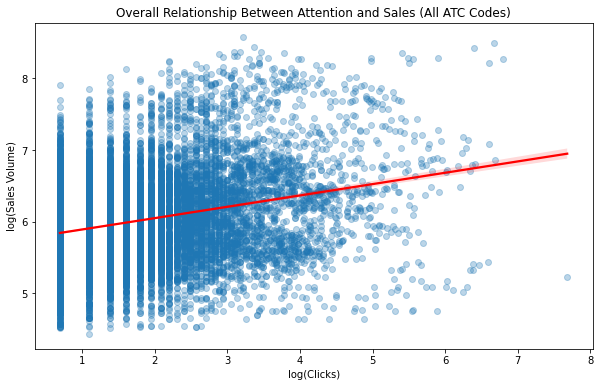

In [124]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.regplot(
    data=merged, 
    x=np.log1p(merged["clicks"]), 
    y=np.log1p(merged["volume"]),
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)
plt.title("Overall Relationship Between Attention and Sales (All ATC Codes)")
plt.xlabel("log(Clicks)")
plt.ylabel("log(Sales Volume)")
plt.show()

1. Positive relationship

The regression line slopes upward, which means:

On average, drugs that get more attention also tend to sell more.

So there is a positive correlation between attention (clicks) and sales.


2. Weak-to-moderate correlation

The slope is fairly shallow, and the cloud is wide, meaning:

The relationship exists, but it’s not strong — attention explains only a small part of the variation in sales.

In other words, some drugs get lots of attention without a big rise in sales, and some sell well even with low attention.


3. Log-scale interpretation

Because both axes are on a log scale:

The relationship is multiplicative rather than linear.

Each step to the right means proportionally more clicks, not just +1 click.

In [123]:
merged[["clicks", "volume"]].corr(method="pearson")

,clicks,volume
clicks,1.000000,0.184641
volume,0.184641,1.000000


It suggests some alignment — when healthcare professionals show more attention (clicks), sales sometimes rise — but many other factors (like pricing, marketing campaigns, or patient population differences) are likely influencing sales more strongly.


It’s not zero, so attention probably plays some role, but it’s not the main driver.


The log-transform is good — it reduces skew from a few high-click or high-sales outliers and gives a more realistic relationship.

Top 5 positively correlated codes:
who_atc_code
A10BD24    0.412602
A10BD23    0.375041
A10BK04    0.361754
A10BD16    0.349802
A10BD21    0.325001
Name: (clicks, volume), dtype: float64

Bottom 5 (weak/negative correlations):
who_atc_code
A10BJ01   -0.042468
A10BD07   -0.002492
A10BD19    0.022096
A10BJ06    0.034347
A10AE56    0.041340
Name: (clicks, volume), dtype: float64


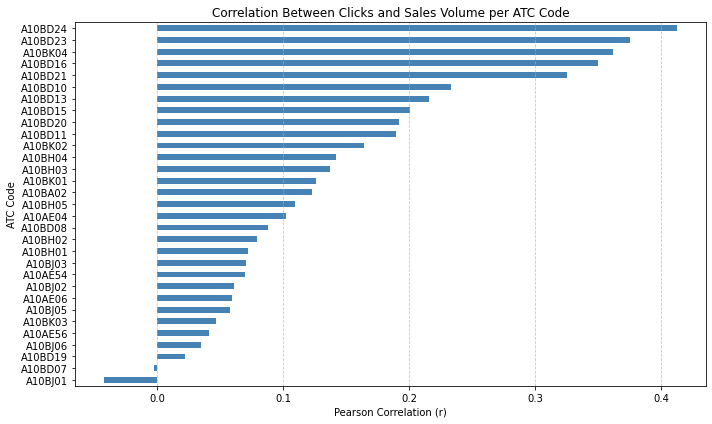

In [118]:
corr_per_code = (
    merged.groupby("who_atc_code")[["clicks", "volume"]]
    .corr(method="pearson")
    .unstack()
    .iloc[:, 1]
    .dropna()
)

top5 = corr_per_code.sort_values(ascending=False).head(5)
bottom5 = corr_per_code.sort_values().head(5)

print("Top 5 positively correlated codes:")
print(top5)

print("\nBottom 5 (weak/negative correlations):")
print(bottom5)

# Plot all correlations
plt.figure(figsize=(10,6))
corr_per_code.sort_values().plot(kind="barh", color="steelblue")
plt.title("Correlation Between Clicks and Sales Volume per ATC Code")
plt.xlabel("Pearson Correlation (r)")
plt.ylabel("ATC Code")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


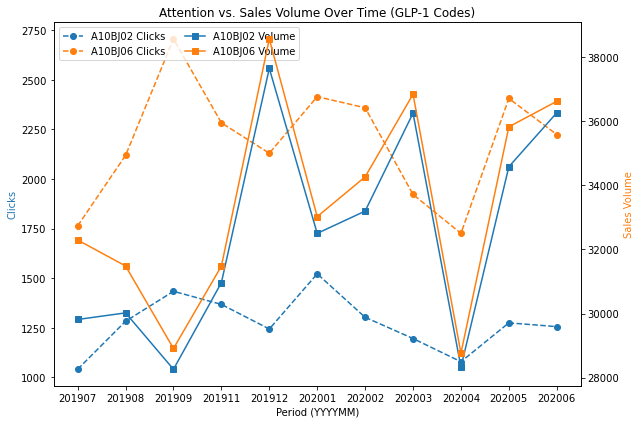

In [ ]:
# Step 1: Group the data by month and ATC code
trend = (
    merged_glp1.groupby(["year_month", "who_atc_code"], as_index=False)[["clicks", "volume", "value"]]
              .sum()
              .sort_values(["who_atc_code", "year_month"])
)

# Step 2: Define which codes to plot
focus_codes = merged_glp1["who_atc_code"].unique()

# Step 3: Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(9,6))

# Left axis — Clicks
for code in focus_codes:
    subset = trend[trend["who_atc_code"] == code]
    ax1.plot(subset["year_month"], subset["clicks"], marker="o", linestyle="--", label=f"{code} Clicks")

# Right axis — Sales Volume
ax2 = ax1.twinx()
for code in focus_codes:
    subset = trend[trend["who_atc_code"] == code]
    ax2.plot(subset["year_month"], subset["volume"], marker="s", label=f"{code} Volume")

# Step 4: Formatting
ax1.set_xlabel("Period (YYYYMM)")
ax1.set_ylabel("Clicks", color="tab:blue")
ax2.set_ylabel("Sales Volume", color="tab:orange")
ax1.set_title("Attention vs. Sales Volume Over Time (GLP-1 Codes)")

# Step 5: Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", ncol=2)

plt.tight_layout()
plt.show()


### Now I'll focus on the specific medicine codes again.

In [128]:
# Aggregate by brick
brick_summary = (
    merged_glp1.groupby(["brick_nr", "who_atc_code"], as_index=False)
    [["clicks", "volume", "value"]].sum()
)

# Correlation per brick
brick_corr = (
    merged_glp1.groupby("brick_nr")
    .apply(lambda x: x["clicks"].corr(x["volume"]))
    .reset_index(name="corr_clicks_volume")
)

brick_corr = brick_corr.sort_values("corr_clicks_volume", ascending=False)
brick_corr.head()


,brick_nr,corr_clicks_volume
57,506,0.517844
18,203,0.434859
29,305,0.329743
30,306,0.321519
54,503,0.317601


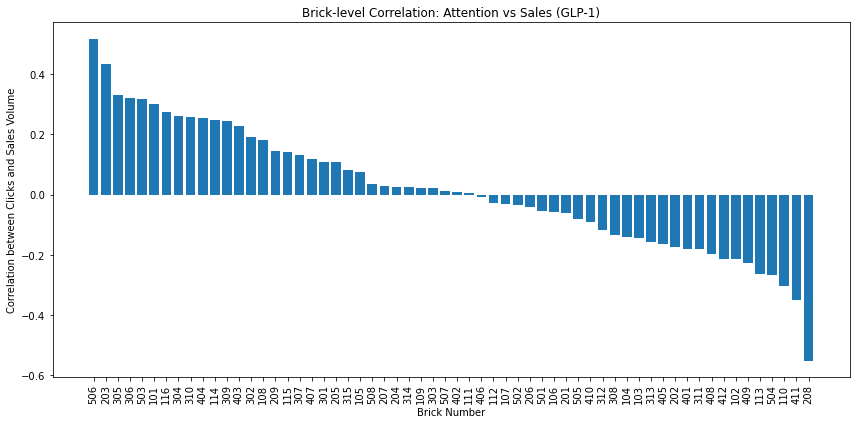

In [129]:
plt.figure(figsize=(12,6))
plt.bar(brick_corr["brick_nr"].astype(str), brick_corr["corr_clicks_volume"])
plt.xticks(rotation=90)
plt.xlabel("Brick Number")
plt.ylabel("Correlation between Clicks and Sales Volume")
plt.title("Brick-level Correlation: Attention vs Sales (GLP-1)")
plt.tight_layout()
plt.show()


In [138]:
brick_summary["attention_efficiency"] = brick_summary["volume_share"] / brick_summary["clicks_share"]
brick_summary = brick_summary.sort_values("attention_efficiency", ascending=False)


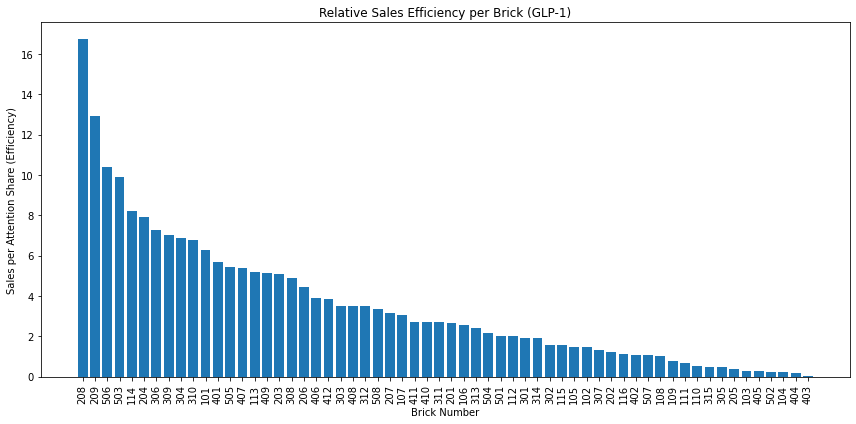

In [139]:
plt.figure(figsize=(12,6))
plt.bar(brick_summary["brick_nr"].astype(str), brick_summary["attention_efficiency"])
plt.xticks(rotation=90)
plt.xlabel("Brick Number")
plt.ylabel("Sales per Attention Share (Efficiency)")
plt.title("Relative Sales Efficiency per Brick (GLP-1)")
plt.tight_layout()
plt.show()


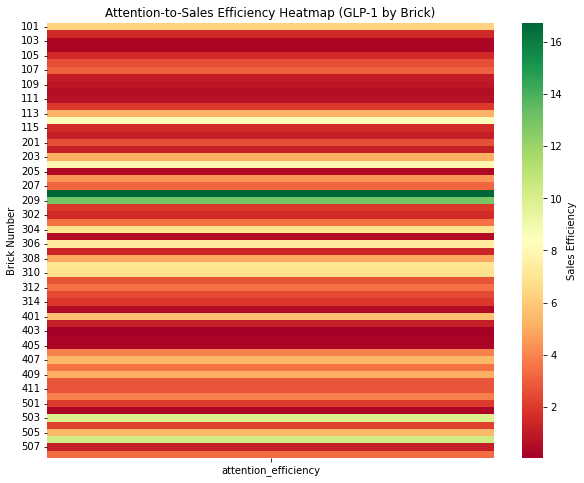

In [140]:
plt.figure(figsize=(10,8))
sns.heatmap(
    brick_summary.pivot_table(values="attention_efficiency", columns=None, index="brick_nr"),
    cmap="RdYlGn",
    cbar_kws={'label': 'Sales Efficiency'}
)
plt.title("Attention-to-Sales Efficiency Heatmap (GLP-1 by Brick)")
plt.ylabel("Brick Number")
plt.show()


This heatmap shows the attention-to-sales efficiency across geographic bricks for GLP-1 products, where greener areas indicate regions converting attention (clicks) into sales more effectively, while redder areas reflect lower efficiency - meaning that some regions (e.g., Brick 209) achieve disproportionately high sales given their attention, whereas others generate interest without corresponding sales impact.